In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle as pkl


import sys
sys.path.append('/home/diogo/miniforge3/envs/core_neuron/lib/python')
import neuron

In [13]:
import h5py
import numpy as np


def load_coreneuron_lfp(filename):

    with h5py.File(filename, "r") as f:

        group = f["report/All"]

        data = group["data"][:]
        element_ids = group["mapping/element_ids"][:]
        node_ids = group["mapping/node_ids"][:]
        index_pointers = group["mapping/index_pointers"][:]
        time_info = group["mapping/time"][:]

    n_cells = len(node_ids)

    n_elements = data.shape[1]

    n_electrodes = n_elements // n_cells

    print("CoreNEURON LFP:")
    print("  data shape:", data.shape)
    print("  cells:", n_cells)
    print("  electrodes:", n_electrodes)
    print("  time:", time_info)

    if n_cells * n_electrodes != n_elements:
        raise ValueError(
            "LFP mapping is not regular: "
            f"{n_elements} elements for {n_cells} cells"
        )

    # time x cell x electrode
    per_cell_lfp = data.reshape(
        data.shape[0],
        n_cells,
        n_electrodes,
    )

    # Sum contribution of every cell.
    #
    # Result:
    # time x electrode
    network_lfp = per_cell_lfp.sum(axis=1)

    return network_lfp, time_info

lfp, info = load_coreneuron_lfp('../data/v2_1s_1000Neurons/coreneuron_lfp/netpyne_lfp.h5')
lfp = np.array(lfp)
time = np.linspace(0, 1000, len(lfp))

CoreNEURON LFP:
  data shape: (20000, 50)
  cells: 50
  electrodes: 1
  time: [0.e+00 1.e+03 5.e-02]


(-5e-05, 5e-05)

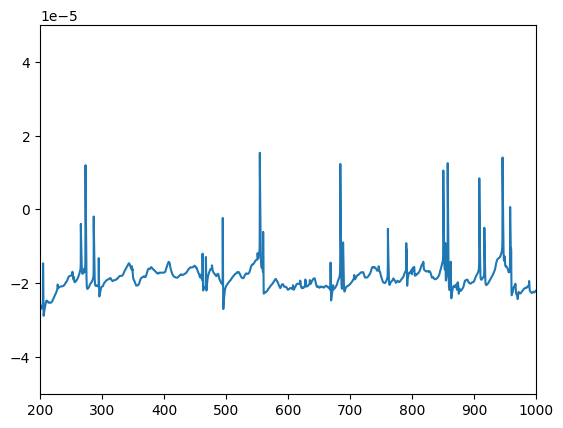

In [15]:
plt.plot(time, lfp[:,0])
plt.xlim(200,1000)
plt.ylim(-0.00005,0.00005)

In [21]:
with open('../data/v2_1s_1000Neurons/v2_1s_1000Neurons_0_data.pkl', 'rb') as file:
    data = pkl.load(file)


spkt = np.array(data['simData']['spkt'])
spkid = np.array(data['simData']['spkid'])
LFP  = np.array(data['simData']['LFP'])
lfp = (LFP[:,0] + LFP[:,1] + LFP[:,2])/3.0

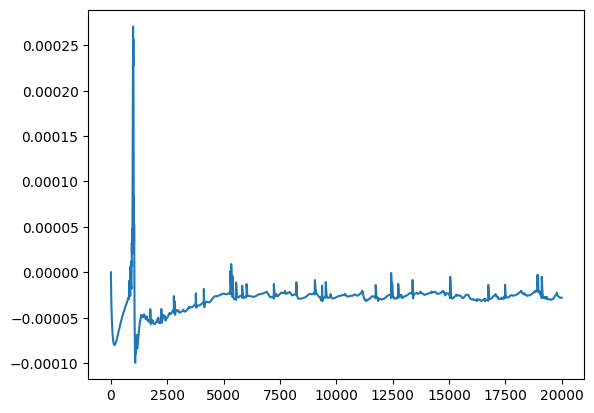

In [22]:
plt.plot(lfp)

In [20]:
data['simData']['LFP']

[[0.0, 0.0, 0.0],
 [-2.5246920358767966e-06, -2.5020992779900553e-06, -2.3578234049637103e-06],
 [-4.883819201495498e-06, -4.83646590510034e-06, -4.554374299914343e-06],
 [-7.093980457284488e-06, -7.023119906079955e-06, -6.611887783947168e-06],
 [-9.178094842354767e-06, -9.085421879717615e-06, -8.553020052204374e-06],
 [-1.1154685125802644e-05, -1.1041856851079501e-05, -1.0395328899903689e-05],
 [-1.3038124961894937e-05, -1.290658019570401e-05, -1.2152067029091995e-05],
 [-1.483674714108929e-05, -1.4687058865092695e-05, -1.3829469025949948e-05],
 [-1.6560084986849688e-05, -1.6393545593018644e-05, -1.5438052287208848e-05],
 [-1.8217313481727615e-05, -1.8034708773484454e-05, -1.6985541151370853e-05],
 [-1.981241257453803e-05, -1.9614702978287823e-05, -1.847603743954096e-05],
 [-2.135336399078369e-05, -2.1141417164471932e-05, -1.9917035388061777e-05],
 [-2.2843734768684953e-05, -2.261815097881481e-05, -2.1311361706466414e-05],
 [-2.428724110359326e-05, -2.404818769718986e-05, -2.266161027

In [45]:
data['simData']['tonic_o']

{_repr_mimebundle_: {}}

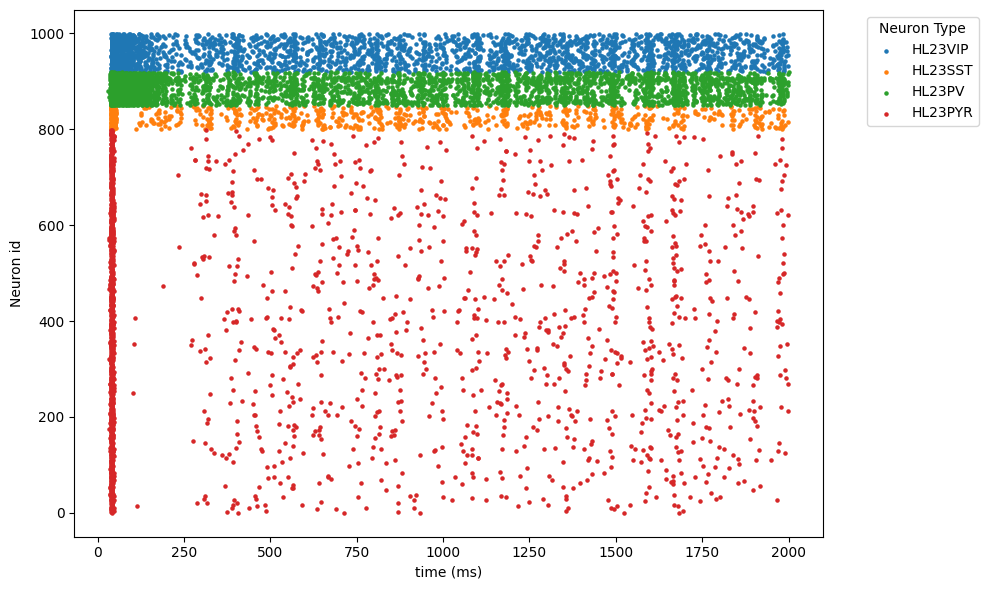

In [3]:
unique_types = set(neuronType.values())

plt.figure(figsize=(10, 6))

for cell_type in unique_types:
    valid_ids = [nid for nid, ctype in neuronType.items() if ctype == cell_type]
    mask = np.isin(spkid, valid_ids)
    plt.scatter(spkt[mask], spkid[mask], label=cell_type, s=5)

plt.xlabel('time (ms)')
plt.ylabel('Neuron id')


plt.legend(title='Neuron Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ensures the legend isn't cut off when saving

plt.show()